## Code de génération du graphe représentant le profile de vitesse saccadé ##

  Accouplement fourche-T -- analyse de désalignement (exact)
  Rayon d'entraînement    R       = 12.5 mm
  Désalignement réel      e       = 3.18 mm (Delta h)
  Erreur de vitesse       min/max = -20.3% / 34.1%
  Vieillissement : distance insuffisante pour atteindre 350 tr/min ;
  profil triangulaire, pic réel = 100.0 tr/min


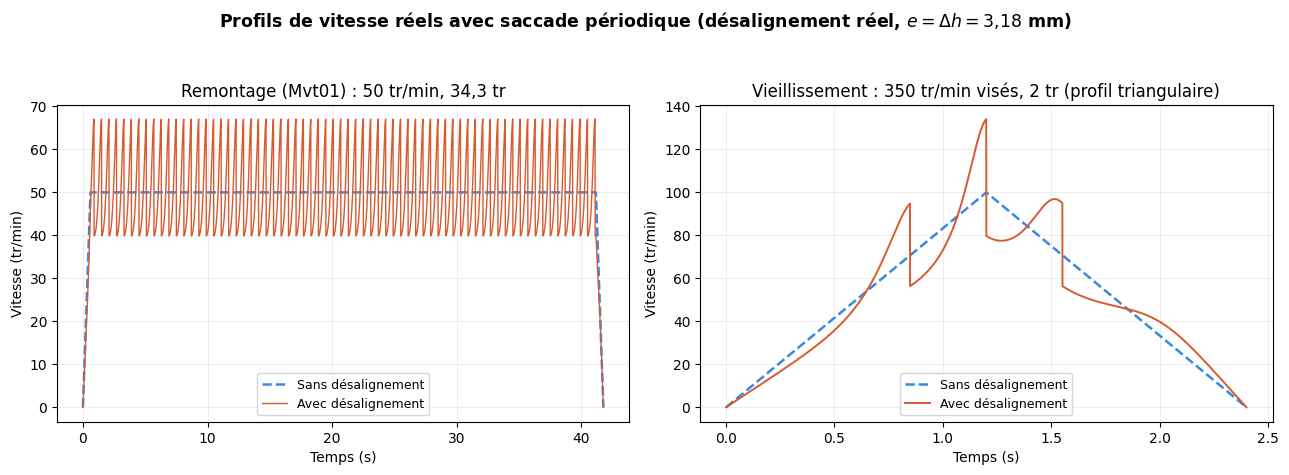

In [1]:
"""
Profils de vitesse réels avec saccade de désalignement
Accouplement fourche-T -- modèle exact, périodique de 180°.

Modèle : un point (ergot) est entraîné à rayon fixe R autour de l'axe moteur.
L'axe tige, décalé radialement de e, "regarde" ce même point. Le rapport de
transmission instantané exact, sur un DEMI-tour, est :

    omega2/omega1 = R*(R + e*cos(alpha)) / (R^2 + e^2 + 2*R*e*cos(alpha))

La fourche en T (tige) étant symétrique (deux bras à 180°), ce rapport se
répète à l'identique tous les 180° de rotation moteur (et non tous les 360°) :
le second bras reproduit exactement le même relais que le premier. On observe
donc une discontinuité de vitesse (mais pas de position) à chaque demi-tour,
lorsque le bras actif change.

Aucune approximation n'est faite (pas de linéarisation, pas d'hypothèse de
petit angle) : e/R = 3.18/12.5 = 0.25 n'est pas négligeable.

Deux profils réellement utilisés par le logiciel sont simulés, avec
accélération limitée à 5000 tr/min² (cf. section Dimensionnement) :
  - Remontage (mode réserve de marche, Mvt01) : 50 tr/min, 34,3 tr (N_tige)
  - Vieillissement accéléré : 350 tr/min visés, 2 tr -- la distance étant
    insuffisante pour atteindre 350 tr/min à cette accélération, le profil
    est en réalité TRIANGULAIRE, avec un pic à 100 tr/min seulement.

Paramètres géométriques :
  - e = 3.18 mm (Delta h, désalignement réel maximal entre mouvements)
  - R = 12.5 mm (rayon d'entraînement, demi-écart de la fourche)
"""

import numpy as np
import matplotlib.pyplot as plt

BLUE = "#378ADD"
ORANGE = "#D85A30"

# ── Paramètres géométriques ────────────────────────────────────────────────────
R = 12.5       # rayon d'entraînement (mm)
E = 3.18       # désalignement radial réel = Delta h (mm)
N = 4000       # points de simulation

# ── Fonctions ─────────────────────────────────────────────────────────────────
def profil_trapeze(v_max, distance, accel, N=N):
    """
    Profil de vitesse trapezoidal (ou triangulaire si la distance est trop
    courte pour atteindre v_max) a acceleration/deceleration constante.
    Retourne t (s), v (tr/min).
    """
    t_acc = v_max / accel                      # min
    d_acc = v_max**2 / (2 * accel)             # tr
    if 2 * d_acc <= distance:
        d_cruise = distance - 2 * d_acc
        t_cruise = d_cruise / v_max
        t1, t2 = t_acc, t_acc + t_cruise
        v_pic = v_max
    else:
        v_pic = np.sqrt(accel * distance)      # profil triangulaire
        t_acc = v_pic / accel
        t1 = t2 = t_acc
    t_total = t2 + t_acc if 2 * d_acc <= distance else 2 * t_acc
    t = np.linspace(0, t_total, N)              # min
    v = np.where(t <= t1, accel * t,
         np.where(t <= t2, v_pic, v_pic - accel * (t - t2)))
    return t * 60, v                            # (s, tr/min)

def with_jitter(t_s, v_ideal, e, R):
    """Vitesse avec saccade periodique de 180 deg (symetrie de la fourche en T)."""
    omega_rad = v_ideal * 2 * np.pi / 60
    dt = t_s[1] - t_s[0]
    alpha = np.cumsum(omega_rad) * dt
    alpha_mod = np.mod(alpha, np.pi)
    ratio = R * (R + e * np.cos(alpha_mod)) / (R**2 + e**2 + 2 * R * e * np.cos(alpha_mod))
    return v_ideal * ratio

def eps_bounds(e, R):
    """Bornes exactes de l'erreur de vitesse relative (min en alpha=0, max en alpha=pi)."""
    return -e / (R + e) * 100, e / (R - e) * 100

eps_min, eps_max = eps_bounds(E, R)
print("=" * 55)
print("  Accouplement fourche-T -- analyse de désalignement (exact)")
print("=" * 55)
print(f"  Rayon d'entraînement    R       = {R:.1f} mm")
print(f"  Désalignement réel      e       = {E:.2f} mm (Delta h)")
print(f"  Erreur de vitesse       min/max = {eps_min:.1f}% / {eps_max:.1f}%")
print("=" * 55)

# ── Profil 1 : remontage (Mvt01), 50 tr/min, 34,3 tr, accel 5000 tr/min² ─────
ACCEL = 5000.0  # tr/min²
t1_s, v1 = profil_trapeze(v_max=50.0, distance=34.30, accel=ACCEL)
actual1 = with_jitter(t1_s, v1, E, R)

# ── Profil 2 : vieillissement, 350 tr/min visés, 2 tr, accel 5000 tr/min² ────
t2_s, v2 = profil_trapeze(v_max=350.0, distance=2.0, accel=ACCEL)
actual2 = with_jitter(t2_s, v2, E, R)
print(f"  Vieillissement : distance insuffisante pour atteindre 350 tr/min ;")
print(f"  profil triangulaire, pic réel = {v2.max():.1f} tr/min")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("Profils de vitesse réels avec saccade périodique (désalignement réel, $e=\Delta h=3{,}18$ mm)",
             fontsize=12.5, fontweight="bold")

ax1.plot(t1_s, v1, color=BLUE, lw=1.8, ls="--", label="Sans désalignement")
ax1.plot(t1_s, actual1, color=ORANGE, lw=1.0, label="Avec désalignement")
ax1.set_xlabel("Temps (s)")
ax1.set_ylabel("Vitesse (tr/min)")
ax1.set_title("Remontage (Mvt01) : 50 tr/min, 34,3 tr")
ax1.legend(fontsize=9, loc="lower center")
ax1.grid(True, lw=0.4, alpha=0.4)

ax2.plot(t2_s, v2, color=BLUE, lw=1.8, ls="--", label="Sans désalignement")
ax2.plot(t2_s, actual2, color=ORANGE, lw=1.4, label="Avec désalignement")
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Vitesse (tr/min)")
ax2.set_title("Vieillissement : 350 tr/min visés, 2 tr (profil triangulaire)")
ax2.legend(fontsize=9, loc="lower center")
ax2.grid(True, lw=0.4, alpha=0.4)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("../../figures/Implementation/profil de vitesse trapezoidale avec saccade.png", dpi=120)
plt.show()
